# Demo: Piglet, Pig, and Value Iteration

This notebook demonstrates the four-file code structure:

```text
Code/
├── piglet.py
├── pig.py
├── value_iteration.py
└── analysis_helpers.py
```

The goal is to verify that:

1. `piglet.py` can run the Piglet game.
2. `pig.py` can run the Pig game.
3. `value_iteration.py` solves the optimal win-probability equations.
4. `analysis_helpers.py` extracts validation results and article-style visualization data.
5. The numerical results align with the paper *Optimal Play of the Dice Game Pig*.

The notebook uses small target scores for fast demonstration. The full Pig game with target score 100 is included as an optional section because it may take longer.

## 1. Import modules

The cell below tries both `Code/` and `code/` as module locations. This is useful if your local folder uses a capital `Code`, as in many Windows projects.

In [ ]:
from pathlib import Path
import sys
import math
import random
import numpy as np
import matplotlib.pyplot as plt

import piglet
import pig
import value_iteration as vi
import analysis_helpers as ah

print("Imported modules successfully.")

Imported modules successfully.
Project root: c:\Users\Lenovo\Desktop\Game_of_Pig_Assessment_3\Code


## 2. Run the games directly

This section verifies that the game simulators work independently of value iteration.

These simulations are random because the games involve coin flips or dice rolls. The random seed controls only the simulated game path, not the value-iteration solution.

In [14]:
# Piglet demo: target score 2, both players use a simple always-flip-until-win policy.
piglet_policy = piglet.make_always_flip_policy(target_score=2)

piglet_final = piglet.play_game(
    policy0=piglet_policy,
    policy1=piglet_policy,
    target_score=2,
    seed=1,
    first_player=0,
)

print("Piglet final state:")
print(piglet_final)

Piglet final state:
PigletState(scores=(2, 0), turn_total=0, current_player=0, winner=0)


In [15]:
# Pig demo: target score 20 for a short game.
# Both players use a simple threshold policy.
pig_policy = pig.make_hold_at_policy(threshold=5, target_score=20)

pig_final = pig.play_game(
    policy0=pig_policy,
    policy1=pig_policy,
    target_score=20,
    seed=2,
    first_player=0,
)

print("Pig final state:")
print(pig_final)

Pig final state:
PigState(scores=(24, 16), turn_total=0, current_player=0, winner=0)


## 3. Verify state-space definitions

The article uses the state

$(i,j,k),$


where:

- `i` is the current player's banked score,
- `j` is the opponent's banked score,
- `k` is the current turn total.

For target score \(G\), valid non-terminal states satisfy:

$
0 \le i < G, \qquad 0 \le j < G, \qquad 0 \le k < G-i.$

For full Pig with \(G=100\), the number of valid states is:

$100 \times (100 + 99 + \cdots + 1) = 505000.$


In [16]:
piglet_spec_2 = piglet.make_spec(target_score=2)
pig_spec_100 = pig.make_spec(target_score=100)

print("Piglet target=2 state count:", vi.count_states(piglet_spec_2))
print("Full Pig target=100 state count:", vi.count_states(pig_spec_100))

assert vi.count_states(pig_spec_100) == 505000
print("State-space check passed.")

Piglet target=2 state count: 6
Full Pig target=100 state count: 505000
State-space check passed.


## 4. Solve Piglet goal=2 and validate exact values

The paper gives exact values for the six non-terminal Piglet states when the target score is 2:

$P_{0,0,0}=\frac47,\quad
P_{0,0,1}=\frac57,\quad
P_{0,1,0}=\frac25,\quad
P_{0,1,1}=\frac35,\quad
P_{1,0,0}=\frac45,\quad
P_{1,1,0}=\frac23.$


This is the strongest small-scale validation of the Bellman equations and the value-iteration implementation.

In [17]:
piglet_result = vi.value_iteration(
    piglet_spec_2,
    tol=1e-12,
    max_iterations=100_000,
    init_value=0.0,
    trace_states=ah.piglet_goal2_trace_states(),
)

V_piglet = piglet_result["V"]
policy_piglet = piglet_result["policy"]

print("Converged:", piglet_result["converged"])
print("Iterations:", piglet_result["iterations"])

errors = ah.check_piglet_goal2_solution(V_piglet, atol=1e-10)
print("Exact-value errors:")
for state, err in errors.items():
    print(f"  {state}: {err:.3e}")

print("Computed vs exact:")
for state, exact in ah.piglet_goal2_exact_values().items():
    print(f"{state}: computed={V_piglet[state]:.12f}, exact={exact:.12f}")

print("Piglet exact-value validation passed.")

Converged: True
Iterations: 64
Exact-value errors:
  (0, 0, 0): 0.000e+00
  (0, 0, 1): 0.000e+00
  (0, 1, 0): 1.404e-12
  (0, 1, 1): 8.001e-13
  (1, 0, 0): 1.060e-12
  (1, 1, 0): 0.000e+00
Computed vs exact:
(0, 0, 0): computed=0.571428571429, exact=0.571428571429
(0, 0, 1): computed=0.714285714286, exact=0.714285714286
(0, 1, 0): computed=0.400000000001, exact=0.400000000000
(0, 1, 1): computed=0.600000000001, exact=0.600000000000
(1, 0, 0): computed=0.799999999999, exact=0.800000000000
(1, 1, 0): computed=0.666666666667, exact=0.666666666667
Piglet exact-value validation passed.


## 5. Plot Piglet convergence data

This reproduces the mathematical object behind the paper's Piglet convergence figure: each curve is the sequence of value-iteration estimates for one state.

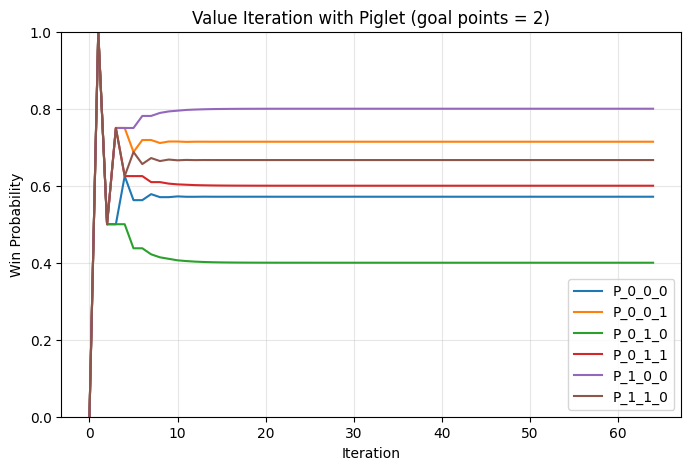

In [18]:
fig2_data = ah.figure2_data_from_result(piglet_result)
ax = ah.plot_figure2_piglet_trace(fig2_data)
plt.show()

## 6. Inspect the Piglet policy table

The policy table stores the optimal action at each state:

- `1` means continue: `flip` for Piglet or `roll` for Pig.
- `0` means `hold`.
- `-1` means invalid or terminal table entry.

For Piglet with target score 2, the paper states that the optimal policy is to keep flipping in every non-terminal state.

In [19]:
print("Piglet policy table entries for valid states:")
for state in vi.iter_states(piglet_spec_2):
    action_code = policy_piglet[state]
    action_name = piglet_spec_2["continue_action"] if action_code == 1 else piglet_spec_2["hold_action"]
    print(f"state={state}, policy={action_code}, action={action_name}")

valid_codes = [policy_piglet[state] for state in vi.iter_states(piglet_spec_2)]
assert all(code == 1 for code in valid_codes)
print("Piglet target=2 policy check passed: all valid states choose flip.")

Piglet policy table entries for valid states:
state=(0, 0, 0), policy=1, action=flip
state=(0, 0, 1), policy=1, action=flip
state=(0, 1, 0), policy=1, action=flip
state=(0, 1, 1), policy=1, action=flip
state=(1, 0, 0), policy=1, action=flip
state=(1, 1, 0), policy=1, action=flip
Piglet target=2 policy check passed: all valid states choose flip.


## 7. Use the solved Piglet policy in the actual game simulator

The value-iteration output is not random. However, once the solved policy is used to play an actual game, the game path is random because it depends on coin flips.

In [20]:
piglet_optimal_policy = vi.optimal_policy_function(piglet_spec_2, V_piglet)

piglet_optimal_game = piglet.play_game(
    policy0=piglet_optimal_policy,
    policy1=piglet_optimal_policy,
    target_score=2,
    seed=123,
    first_player=0,
)

print("Piglet game using solved optimal policy:")
print(piglet_optimal_game)

Piglet game using solved optimal policy:
PigletState(scores=(2, 0), turn_total=0, current_player=0, winner=0)


## 8. Small Pig: compare full value iteration and partitioned value iteration

The full Pig game has 505,000 states. For a fast correctness test, we use a smaller Pig target score.

This section checks that:

1. The general full Jacobi value iteration works.
2. The article-aligned partitioned value iteration works.
3. Both produce the same value table on a small Pig problem.

The partitioned algorithm is the one intended for full Pig. It solves states by descending score sum \(i+j\), matching the acceleration idea described in the paper.

In [21]:
small_target = 20
small_pig_spec = pig.make_spec(target_score=small_target)

small_full = vi.value_iteration(
    small_pig_spec,
    tol=1e-11,
    max_iterations=100_000,
    init_value=0.0,
)

small_part = vi.partitioned_value_iteration(
    small_pig_spec,
    tol=1e-11,
    max_local_iterations=100_000,
    init_value=0.0,
    progress=False,
)

V_full = small_full["V"]
V_part = small_part["V"]
policy_small = small_part["policy"]

valid_mask = vi.valid_state_mask(small_pig_spec)
max_abs_diff = np.nanmax(np.abs(V_full[valid_mask] - V_part[valid_mask]))

print("Small Pig target:", small_target)
print("Full VI converged:", small_full["converged"], "iterations:", small_full["iterations"])
print("Partitioned VI converged:", small_part["converged"])
print("Max absolute difference between methods:", max_abs_diff)

assert max_abs_diff < 1e-8
print("Small Pig solver consistency check passed.")

Small Pig target: 20
Full VI converged: True iterations: 122
Partitioned VI converged: True
Max absolute difference between methods: 1.0141476547431694e-10
Small Pig solver consistency check passed.


## 9. Summarize the small Pig solution

The summary reports:

- target score,
- number of valid states,
- start-state win probability \(P_{0,0,0}\),
- number of states where continuing is optimal,
- number of states where holding is optimal.

For `target_score=20`, the start probability is for the small demo game, not the full paper game.

In [22]:
small_summary = ah.summarize_solution(small_pig_spec, V_part, policy_small)
small_summary

{'target_score': 20,
 'n_valid_states': 4200,
 'start_win_probability': 0.6155585498033931,
 'n_continue_states': 4200,
 'n_hold_states': 0}

## 10. Use the solved small Pig policy in the Pig simulator

This converts the solved value table into a real game-playing policy.

Important distinction:

- Value iteration is deterministic.
- Running a game is random because dice rolls are random.

In [23]:
small_optimal_policy = vi.optimal_policy_function(small_pig_spec, V_part)
small_baseline_policy = pig.make_hold_at_policy(threshold=5, target_score=small_target)

opt_vs_opt = pig.play_game(
    policy0=small_optimal_policy,
    policy1=small_optimal_policy,
    target_score=small_target,
    seed=10,
    first_player=0,
)

opt_vs_baseline = pig.play_game(
    policy0=small_optimal_policy,
    policy1=small_baseline_policy,
    target_score=small_target,
    seed=11,
    first_player=0,
)

print("Small Pig, optimal vs optimal:")
print(opt_vs_opt)
print("Small Pig, optimal vs baseline:")
print(opt_vs_baseline)

Small Pig, optimal vs optimal:
PigState(scores=(21, 0), turn_total=0, current_player=0, winner=0)
Small Pig, optimal vs baseline:
PigState(scores=(22, 0), turn_total=0, current_player=0, winner=0)


## 11. Extract visualization data for the small Pig game

The paper visualizes several objects:

- roll/hold boundary,
- fixed-opponent-score cross-section,
- reachable states,
- reachable states where rolling is optimal,
- win-probability contours.

Here we generate the same types of data on the small Pig game. The shapes are not expected to match the full paper figures exactly because the target score is 20 rather than 100.

In [24]:
def choose_valid_opponent_score(policy, preferred=None):
    # Choose an opponent score whose cross-section has at least one finite boundary.
    B = ah.hold_boundary(policy)
    G = B.shape[0]

    if preferred is not None and 0 <= preferred < G and np.isfinite(B[:, preferred]).any():
        return preferred

    for j in range(G):
        if np.isfinite(B[:, j]).any():
            return j

    return None

fig3_data = ah.figure3_boundary_data(policy_small)

j_demo = choose_valid_opponent_score(policy_small, preferred=min(30, small_target - 1))
if j_demo is None:
    print("No valid finite cross-section boundary was found for the small Pig policy.")
    fig4_data = None
else:
    fig4_data = ah.figure4_cross_section_data(policy_small, opponent_score=j_demo)
    print("Chosen opponent score for cross-section:", j_demo)

fig5_data = ah.figure5_reachable_data(small_pig_spec, policy_small, opponent_mode="any")
fig6_data = ah.figure6_reachable_continue_data(small_pig_spec, policy_small, opponent_mode="any")
fig7_data = ah.figure7_probability_contour_data(
    small_pig_spec,
    V_part,
    levels=(0.03, 0.09, 0.27, 0.81),
)

print("Boundary points:", fig3_data["points"].shape)
print("Reachable points:", fig5_data["points"].shape)
print("Reachable-continue points:", fig6_data["points"].shape)

No valid finite cross-section boundary was found for the small Pig policy.
Boundary points: (0,)
Reachable points: (361, 3)
Reachable-continue points: (361, 3)


## 12. Plot small Pig article-style figures

These plots are mainly functional checks. The full article visualizations should be generated with `target_score=100`.

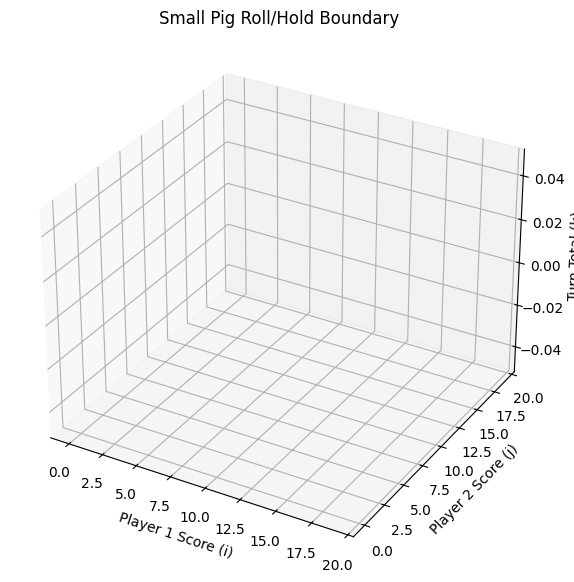

Skipping Figure 4-style plot because there is no finite boundary cross-section.


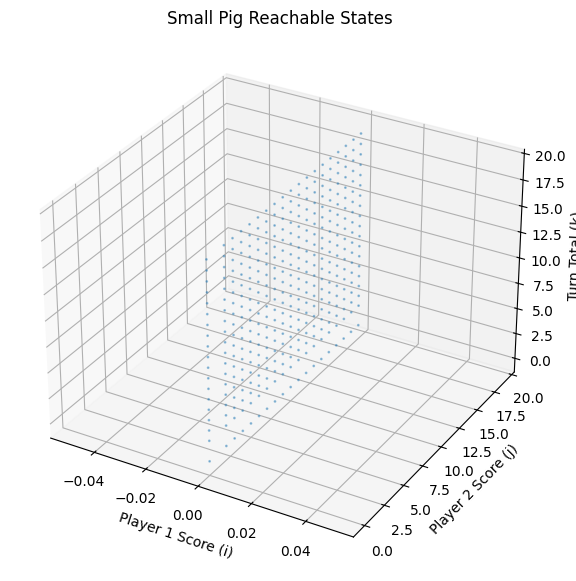

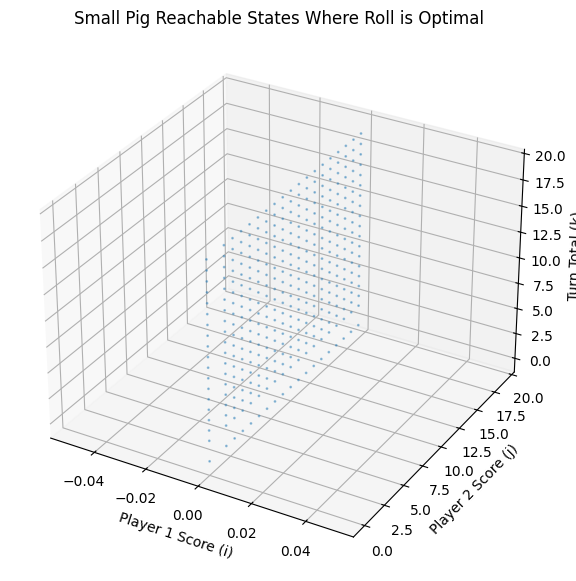

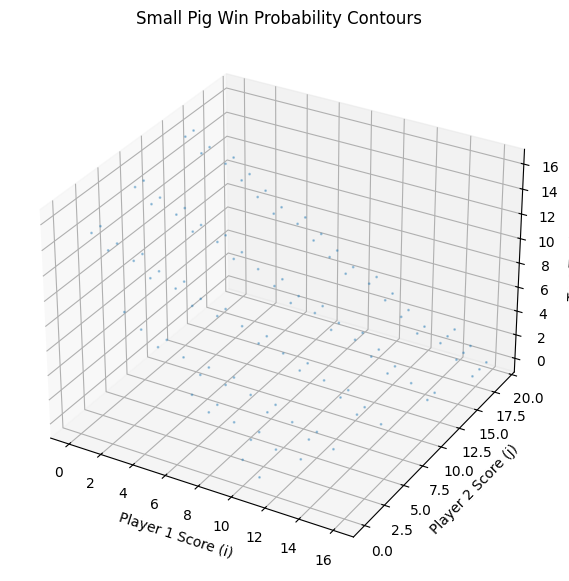

In [25]:
ah.plot_figure3_policy_boundary(fig3_data, title="Small Pig Roll/Hold Boundary")
plt.show()

if fig4_data is not None:
    ah.plot_figure4_cross_section(
        fig4_data,
        hold_at_threshold=min(20, small_target - 1),
        title="Small Pig Boundary Cross-section",
    )
    plt.show()
else:
    print("Skipping Figure 4-style plot because there is no finite boundary cross-section.")

ah.plot_figure5_reachable_states(fig5_data, title="Small Pig Reachable States")
plt.show()

ah.plot_figure6_reachable_continue_states(fig6_data, title="Small Pig Reachable States Where Roll is Optimal")
plt.show()

ah.plot_figure7_probability_contours(fig7_data, title="Small Pig Win Probability Contours")
plt.show()

## 13. Solve the full Pig game from the paper

The full paper setting is:

```text
Pig target score = 100
```

The paper reports that if both players play optimally, the starting player wins approximately:

$P_{0,0,0} \approx 0.5306.$

This cell is disabled by default because the full computation can take longer. Set `RUN_FULL_PIG = True` to run it.

In [26]:
RUN_FULL_PIG = True 

if RUN_FULL_PIG:
    full_pig_spec = pig.make_spec(target_score=100)

    full_result = vi.partitioned_value_iteration(
        full_pig_spec,
        tol=1e-12,
        max_local_iterations=100_000,
        init_value=0.0,
        progress=True,
    )

    full_V = full_result["V"]
    full_policy = full_result["policy"]

    print("Full Pig converged:", full_result["converged"])
    print("P[0,0,0] =", full_V[0, 0, 0])

    err = ah.check_pig_start_probability(full_V, expected=0.5306, atol=1e-3)
    print("Start-probability check passed. Absolute error:", err)

    full_summary = ah.summarize_solution(full_pig_spec, full_V, full_policy)
    print("Full Pig summary:")
    print(full_summary)
else:
    print("Full Pig solve skipped. Set RUN_FULL_PIG = True to run it.")

Solving score_sum=198
Solving score_sum=197
Solving score_sum=196
Solving score_sum=195
Solving score_sum=194
Solving score_sum=193
Solving score_sum=192
Solving score_sum=191
Solving score_sum=190
Solving score_sum=189
Solving score_sum=188
Solving score_sum=187
Solving score_sum=186
Solving score_sum=185
Solving score_sum=184
Solving score_sum=183
Solving score_sum=182
Solving score_sum=181
Solving score_sum=180
Solving score_sum=179
Solving score_sum=178
Solving score_sum=177
Solving score_sum=176
Solving score_sum=175
Solving score_sum=174
Solving score_sum=173
Solving score_sum=172
Solving score_sum=171
Solving score_sum=170
Solving score_sum=169
Solving score_sum=168
Solving score_sum=167
Solving score_sum=166
Solving score_sum=165
Solving score_sum=164
Solving score_sum=163
Solving score_sum=162
Solving score_sum=161
Solving score_sum=160
Solving score_sum=159
Solving score_sum=158
Solving score_sum=157
Solving score_sum=156
Solving score_sum=155
Solving score_sum=154
Solving sc

## 14. Optional: generate full paper-style visualization data

Run this only after the full Pig solve has completed. The data objects correspond to the paper's main visualizations:

- Figure 3: roll/hold boundary,
- Figure 4: cross-section at opponent score 30,
- Figure 5: reachable states,
- Figure 6: reachable states where rolling is optimal,
- Figure 7: win-probability contours at 3%, 9%, 27%, and 81%.

Full Figure 3 boundary points: (5563, 3)
Full Figure 5 reachable points: (179577, 3)
Full Figure 6 reachable-roll points: (160879, 3)


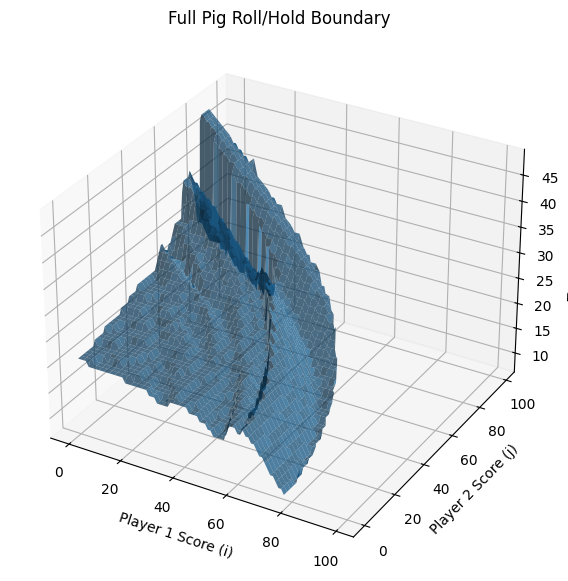

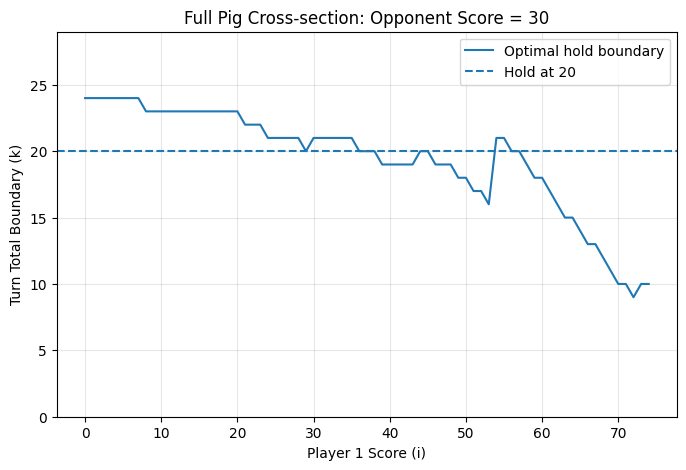

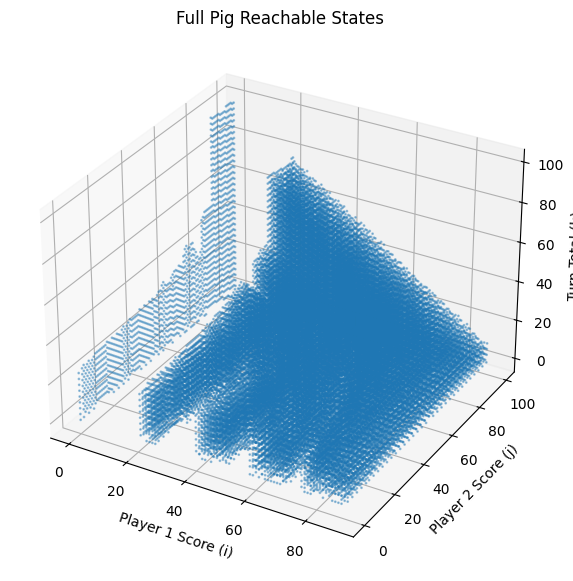

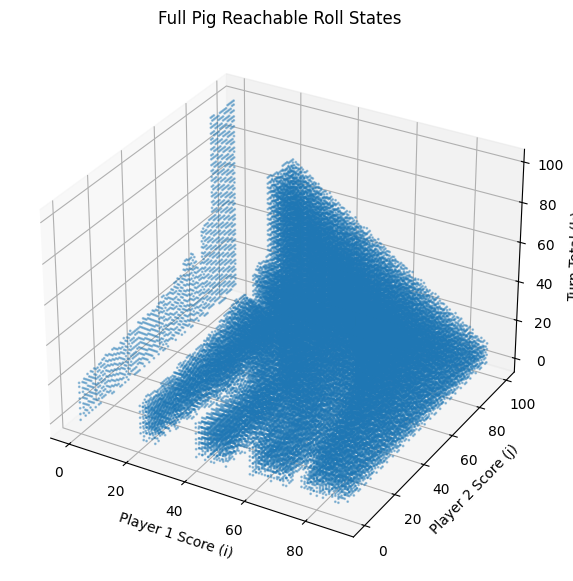

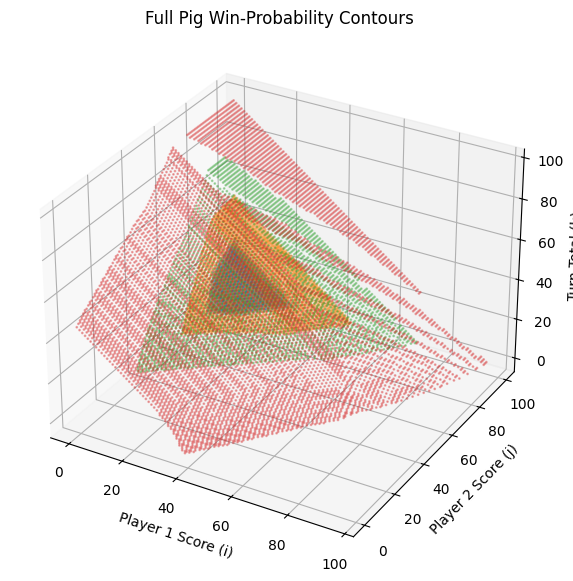

In [30]:
if RUN_FULL_PIG:
    full_fig3_data = ah.figure3_boundary_data(full_policy)
    full_fig4_data = ah.figure4_cross_section_data(full_policy, opponent_score=30)
    full_fig5_data = ah.figure5_reachable_data(full_pig_spec, full_policy, opponent_mode="any")
    full_fig6_data = ah.figure6_reachable_continue_data(full_pig_spec, full_policy, opponent_mode="any")
    full_fig7_data = ah.figure7_probability_contour_data(
        full_pig_spec,
        full_V,
        levels=(0.03, 0.09, 0.27, 0.81),
    )

    print("Full Figure 3 boundary points:", full_fig3_data["points"].shape)
    print("Full Figure 5 reachable points:", full_fig5_data["points"].shape)
    print("Full Figure 6 reachable-roll points:", full_fig6_data["points"].shape)
else:
    print("Full figure-data generation skipped because RUN_FULL_PIG is False.")
    


ah.plot_figure3_policy_boundary(
    full_fig3_data,
    title="Full Pig Roll/Hold Boundary"
)
plt.show()

ah.plot_figure4_cross_section(
    full_fig4_data,
    hold_at_threshold=20,
    title="Full Pig Cross-section: Opponent Score = 30"
)
plt.show()

ah.plot_figure5_reachable_states(
    full_fig5_data,
    max_points=60000,
    title="Full Pig Reachable States"
)
plt.show()

ah.plot_figure6_reachable_continue_states(
    full_fig6_data,
    max_points=60000,
    title="Full Pig Reachable Roll States"
)
plt.show()

ah.plot_figure7_probability_contours(
    full_fig7_data,
    title="Full Pig Win-Probability Contours"
)
plt.show()

## 15. Optional: use the full optimal policy in the actual Pig simulator

This is not required to extract the article's main conclusions, because the value table `V` and policy table already contain the full solution. However, it is useful as a practical demonstration that the solved policy can actually play the game.

In [31]:
if RUN_FULL_PIG:
    full_optimal_policy = vi.optimal_policy_function(full_pig_spec, full_V)

    final_state = pig.play_game(
        policy0=full_optimal_policy,
        policy1=pig.hold_at_20_policy,
        target_score=100,
        seed=6006011,
        first_player=0,
    )

    print("Full Pig, optimal first player vs hold-at-20 second player:")
    print(final_state)
else:
    print("Full policy game simulation skipped because RUN_FULL_PIG is False.")

Full Pig, optimal first player vs hold-at-20 second player:
PigState(scores=(104, 45), turn_total=0, current_player=0, winner=0)


In [33]:
if RUN_FULL_PIG:
    import random

    N_GAMES = 200_000
    rng = random.Random(20260430)

    optimal_wins = 0
    hold20_wins = 0

    for game_id in range(N_GAMES):
        game_seed = rng.randint(0, 10**12)

        final_state = pig.play_game(
            policy0=full_optimal_policy,
            policy1=pig.hold_at_20_policy,
            target_score=100,
            seed=game_seed,
            first_player=0,
        )

        if final_state.winner == 0:
            optimal_wins += 1
        else:
            hold20_wins += 1

    optimal_win_rate = optimal_wins / N_GAMES
    hold20_win_rate = hold20_wins / N_GAMES

    print("Optimal policy vs hold-at-20 policy")
    print(f"Number of games: {N_GAMES}")
    print(f"Optimal wins: {optimal_wins}")
    print(f"Hold-at-20 wins: {hold20_wins}")
    print(f"Optimal win rate: {optimal_win_rate:.4f}")
    print(f"Hold-at-20 win rate: {hold20_win_rate:.4f}")
    print("Article reference: optimal first player vs hold-at-20 second player ≈ 0.5874")

else:
    print("Multi-game simulation skipped because RUN_FULL_PIG is False.")

Optimal policy vs hold-at-20 policy
Number of games: 200000
Optimal wins: 114840
Hold-at-20 wins: 85160
Optimal win rate: 0.5742
Hold-at-20 win rate: 0.4258
Article reference: optimal first player vs hold-at-20 second player ≈ 0.5874


## 16. Final checklist

If the notebook ran successfully, the following should be true:

1. Piglet and Pig can both run as games.
2. The state count for full Pig is 505000.
3. Piglet target=2 reproduces the exact values from the paper.
4. Piglet target=2 chooses `flip` in all valid states.
5. Full and partitioned value iteration agree on a small Pig instance.
6. The solved policy can be converted into a real game-playing policy.
7. The helper functions can extract boundary, reachability, and probability-contour data.
8. The optional full Pig solve should give $P_{0,0,0}\approx 0.5306$, matching the paper.